[INFO] Memuat Dataset Venezuela 3C: extracted_data_3c_venez_v3.json


2026-07-16 06:17:20.842641: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-07-16 06:17:20.842663: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2026-07-16 06:17:20.842672: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.66 GB
2026-07-16 06:17:20.842693: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-16 06:17:20.842704: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


No training configuration found in save file, so the model was *not* compiled. Compile it manually.
Estimasi statistik embedding global (KDE)...
Memproses 3942 data Venezuela 3C...
Inference Venezuela 3C: 100%|██████████| 3942/3942 [01:31<00:00, 43.23it/s]

VENEZUELA DOMAIN 3C ACCURACY: 0.5343734145104008
VENEZUELA DOMAIN 3C F1-SCORE: 0.5310571147712818
Evaluasi Venezuela 3C Selesai.


Accuracy: [0.5343734145104008, 0.5343734145104008]
Accuracy (avg.): 0.5343734145104008
True positive rate: [0.6184677828513445, 0.45027904616945713]
True positive rate (avg.): 0.5343734145104008
True negative rate: [0.45027904616945713, 0.6184677828513445]
True negative rate (avg.): 0.5343734145104008
Positive predictive value: [0.5294245385450597, 0.5413235742604453]
Positive predictive value (avg.): 0.5353740564027526
Negative predictive value: [0.5413235742604453, 0.5294245385450597]
Negative predictive value (avg.): 0.5353740564027526
False positive rate: [0.5497209538305429, 0.3815322171486555]
False positive rate (avg.): 0.4656265854895992
False negative rate: [0.3815322171486555, 0.5497209538305429]
False negative rate (avg.): 0.4656265854895992
False discovery rate: [0.4705754614549403, 0.45867642573955475]
False discovery rate (avg.): 0.46462594359724757
F1-score: [0.5704925704925704, 0.49162165904999305]
F1-score (avg.): 0.5310571147712818
[INFO] Grafik metrik tersimpan di: /

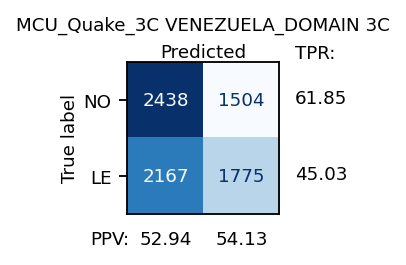

In [1]:
# -*- coding: utf-8 -*-
"""
EVALUASI MCU-QUAKE 3C - VENEZUELA DOMAIN
Menggunakan model pre-trained MCU-Quake 5-20 dan embedding UUSS.
"""

from Library import utils, dataset
import os
from tensorflow import keras
from tqdm import tqdm
import numpy as np
from datetime import datetime
import logging
import matplotlib.pyplot as plt

# Fungsi plot (sama seperti sebelumnya)
def plot_comprehensive_metrics(metrics, save_path):
    labels = ['Accuracy', 'Recall', 'Precision', 'FPR', 'F1-Score']
    keys = [
        'Accuracy (avg.)', 
        'True positive rate (avg.)', 
        'Positive predictive value (avg.)', 
        'False positive rate (avg.)', 
        'F1-score (avg.)'
    ]
    values = [metrics.get(k, 0) for k in keys]
    plt.figure(figsize=(12, 6))
    bars = plt.bar(labels, values, color=['#2c3e50', '#3498db', '#e67e22', '#e74c3c', '#27ae60'])
    plt.ylim(0, 1.0)
    plt.ylabel('Score')
    plt.title('Performance Metrics Evaluation (Average) - Venezuela 3C')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom')
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.close()
    print(f"[INFO] Grafik metrik tersimpan di: {save_path}")

# =============================================
# 1. KONFIGURASI - VENEZUELA 3C
# =============================================
KEY_DATA_DIR = "/Volumes/Extreme SSD/venezuela_data_earthquake/json_venezuela"
KEY_TEST_FILE = "extracted_data_3c_venez_v3.json"  # ← file JSON 3C Venezuela

DATA_TAG = "VENEZUELA_DOMAIN"             # ← tag untuk penamaan output
MODEL_TAG = "MCU_Quake_3C"
INPUT_WIN = 7 
SAMPLING_RATE = 100

true_labels = ["NO", "LE"]
source_to_code = {"noise": 0, "le": 1}

# Path Model dan Embedding (tetap menggunakan UUSS / STEAD)
BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/mcquake_ori_file/Code & Figure demo"
MODEL_PATH = os.path.join(BASE_REP, "Pre-trained model/MCU-Quake 5-20")

# Pilih salah satu embedding (saya sarankan UUSS karena lebih umum)
EMB_DIR = os.path.join(BASE_REP, "Typical embedding/Embedding_data train 3C, UUSS n11275 std15, 30120909")
# EMB_DIR = os.path.join(BASE_REP, "Typical embedding/Embedding_data train 3C, STEAD norm7 mag3 L n61099, 30172538")

# Output untuk hasil evaluasi Venezuela
SAVE_BASE = '/Volumes/Extreme SSD/venezuela_data_earthquake/visualisasi_venezuela'

# =============================================
# 2. PREPARE FILES
# =============================================
print(f"[INFO] Memuat Dataset Venezuela 3C: {KEY_TEST_FILE}")
test_data = dataset.load_json_data(os.path.join(KEY_DATA_DIR, KEY_TEST_FILE))

now = datetime.now()
time_str = now.strftime("%d%H%M%S")
save_dir = os.path.join(SAVE_BASE, f"{MODEL_TAG}_{DATA_TAG}_{time_str}")
if not os.path.exists(save_dir): 
    os.makedirs(save_dir)

# Logger
log_file_path = os.path.join(save_dir, "task_log_venezuela_3c.txt")
logging.basicConfig(filename=log_file_path, level=logging.INFO, filemode='w',
                    format='%(asctime)s - [%(levelname)s]: %(message)s')
logger = logging.getLogger()
logger.addHandler(logging.StreamHandler())

# Load Model & Embeddings
embedding_model = keras.models.load_model(filepath=MODEL_PATH)
embedding_Z = dataset.load_embedding_data(EMB_DIR, "Embedding data, Z.json")
embedding_N = dataset.load_embedding_data(EMB_DIR, "Embedding data, N.json")
embedding_E = dataset.load_embedding_data(EMB_DIR, "Embedding data, E.json")

logger.info(f"Estimasi statistik embedding global (KDE)...")
embeddings_3C_PDFs = utils.embedding_PDFs_3D(embedding_Z, embedding_N, embedding_E)

# =============================================
# 3. EVALUASI
# =============================================
total_true_3C, total_pred_3C = [], []
num_points = int(INPUT_WIN * SAMPLING_RATE)
keys_list = list(test_data.keys())

logger.info(f"Memproses {len(keys_list)} data Venezuela 3C...")

for i in tqdm(range(len(keys_list)), desc="Inference Venezuela 3C"):
    record_key = keys_list[i]
    record = test_data[record_key]
    quake_label = record["type"]  # 'le' atau 'no' (sesuai dengan dataset)

    try:
        # Sinyal & Noise 3C (sesuai format JSON)
        Z_n, N_n, E_n = record["Z_noise"][-num_points:], record["N_noise"][-num_points:], record["E_noise"][-num_points:]
        Z_s, N_s, E_s = record["Z"][:num_points], record["N"][:num_points], record["E"][:num_points]

        # Embeddings
        _in_Zn, _in_Nn, _in_En = utils.latent_codes_1D(Z_n, embedding_model), utils.latent_codes_1D(N_n, embedding_model), utils.latent_codes_1D(E_n, embedding_model)
        _in_Zs, _in_Ns, _in_Es = utils.latent_codes_1D(Z_s, embedding_model), utils.latent_codes_1D(N_s, embedding_model), utils.latent_codes_1D(E_s, embedding_model)

        # Inferensi 3C KDE - Noise
        emb_n_3c = np.array([_in_En, _in_Nn, _in_Zn]).reshape(1,-1)
        p_n_3c, _, _ = utils.infer_3C_PDFs(emb_n_3c, embeddings_3C_PDFs, "Kernel")
        
        # Inferensi 3C KDE - Earthquake
        emb_s_3c = np.array([_in_Es, _in_Ns, _in_Zs]).reshape(1,-1)
        p_s_3c, _, _ = utils.infer_3C_PDFs(emb_s_3c, embeddings_3C_PDFs, "Kernel")

        # Mapping label: noise = 0, earthquake = 1
        total_true_3C.extend([0, 1]) 
        total_pred_3C.extend([1 if p_n_3c >= 1 else 0, 1 if p_s_3c >= 1 else 0])
        
    except Exception as e:
        logger.error(f"Error pada {record_key}: {e}")
        continue

# =============================================
# 4. METRICS & SAVE
# =============================================
matrix_3C, metrics_3C = utils.calc_confusion_metrics(total_true_3C, total_pred_3C)

# Confusion Matrix
fig_3C = utils.plot_confusion(f"{MODEL_TAG} {DATA_TAG} 3C", true_labels, matrix_3C, metrics_3C)
fig_3C.savefig(os.path.join(save_dir, "venezuela_domain_3C_KDE.jpg"), dpi=300)

# Save metrics ke JSON
dataset.save_json_data(os.path.join(save_dir, "venezuela_domain_3C_metrics.json"), metrics_3C)

# Plot comprehensive metrics
plot_comprehensive_metrics(metrics_3C, os.path.join(save_dir, "venezuela_domain_3C_metrics_bar.jpg"))

logger.info("\n" + "="*40)
logger.info(f"VENEZUELA DOMAIN 3C ACCURACY: {metrics_3C.get('Accuracy (avg.)')}")
logger.info(f"VENEZUELA DOMAIN 3C F1-SCORE: {metrics_3C.get('F1-score (avg.)')}")
logger.info("="*40)
logger.info("Evaluasi Venezuela 3C Selesai.")